In [1]:
import os
import gc
import json
import random
import psutil
import ast
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
MODEL_ID  = "HuggingFaceTB/SmolVLM-500M-Instruct"
LOG_DIR   = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(ast.literal_eval)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
total_train_examples = train_df["num_choices"].sum()
print(f"Expanded NLI train examples: {total_train_examples:,}")

Train: 3,109 | Val: 1,048 | Test: 1,008
Expanded NLI train examples: 9,666


In [3]:
def build_nli_prompt(row, choice_text, include_answer=False, max_context_chars=2000):
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"
    text += f"Question: {row['question']}\n"
    text += f"Proposed answer: {choice_text}\n"
    text += "Is this the correct answer? Yes or No."

    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"

    if include_answer:
        prompt += " Yes" if include_answer == "yes" else " No"

    return prompt

# Verify
sample = train_df.iloc[0]
for j, choice in enumerate(sample["choices"]):
    is_correct = (j == int(sample["answer"]))
    target     = "yes" if is_correct else "no"
    prompt     = build_nli_prompt(sample, choice, include_answer=target)
    print(f"Choice {chr(65+j)} ({'CORRECT' if is_correct else 'wrong'}): ends with '{prompt[-10:]}'")

Choice A (wrong): ends with 'istant: No'
Choice B (wrong): ends with 'istant: No'
Choice C (CORRECT): ends with 'stant: Yes'


In [4]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

processor.image_processor.do_image_splitting = False
processor.image_processor.size              = {"longest_edge": 512}
processor.image_processor.max_image_size    = {"longest_edge": 512}

yes_token = processor.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
no_token  = processor.tokenizer("No",  add_special_tokens=False)["input_ids"][0]
print(f"'Yes' token id: {yes_token}")
print(f"'No'  token id: {no_token}")
print(f"do_image_splitting: {processor.image_processor.do_image_splitting}")
print(f"size: {processor.image_processor.size}")

'Yes' token id: 10539
'No'  token id: 5230
do_image_splitting: False
size: {'longest_edge': 512}


In [5]:
class NLIDataset(Dataset):
    def __init__(self, df, data_dir, max_context_chars=2000):
        self.data_dir          = data_dir
        self.max_context_chars = max_context_chars
        self.examples          = []

        for _, row in df.iterrows():
            img_path = data_dir / row["image_path"]
            for j, choice in enumerate(row["choices"]):
                is_correct = (j == int(row["answer"]))
                self.examples.append({
                    "image_path": img_path,
                    "prompt":     build_nli_prompt(
                                      row, choice,
                                      include_answer="yes" if is_correct else "no",
                                      max_context_chars=max_context_chars
                                  ),
                    "label":      1 if is_correct else 0,
                })

        print(f"NLIDataset: {len(self.examples):,} examples from {len(df):,} samples")
        labels = [ex["label"] for ex in self.examples]
        print(f"  Yes (correct):   {sum(labels):,}")
        print(f"  No (incorrect):  {len(labels)-sum(labels):,}")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex  = self.examples[idx]
        img = Image.open(ex["image_path"]).convert("RGB")
        return {
            "image": img,
            "text":  ex["prompt"],
            "label": ex["label"],
        }

train_nli_ds = NLIDataset(train_df, DATA_DIR)

NLIDataset: 9,666 examples from 3,109 samples
  Yes (correct):   3,109
  No (incorrect):  6,557


In [6]:
assistant_token_ids = processor.tokenizer(
    "Assistant:", add_special_tokens=False
)["input_ids"]
print(f"'Assistant:' token ids: {assistant_token_ids}")

def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    labels  = [b["label"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    loss_labels = inputs["input_ids"].clone()
    loss_labels[loss_labels == processor.tokenizer.pad_token_id] = -100

    for i in range(loss_labels.shape[0]):
        seq   = inputs["input_ids"][i].tolist()
        found = False
        for pos in range(len(seq) - len(assistant_token_ids)):
            if seq[pos:pos + len(assistant_token_ids)] == assistant_token_ids:
                loss_labels[i, :pos + len(assistant_token_ids)] = -100
                found = True
                break
        if not found:
            loss_labels[i, :] = -100

    inputs["labels"] = loss_labels
    return inputs, torch.tensor(labels)

def score_choices_nli(model, processor, image, row, choices, max_context_chars=2000):
    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, include_answer=False,
                                  max_context_chars=max_context_chars)
        inputs = processor(
            text=[prompt], images=[image],
            return_tensors="pt", padding=True
        )
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]

        score = logits[0, yes_token].item() - logits[0, no_token].item()
        scores.append(score)

        del outputs, logits, inputs
        torch.cuda.empty_cache()

    return int(torch.tensor(scores).argmax().item())

# Verify collate
sample_batch = [train_nli_ds[i] for i in range(4)]
inputs_test, labels_test = collate_fn(sample_batch)
for i in range(4):
    label_ids  = inputs_test["labels"][i]
    valid_mask = label_ids != -100
    valid_ids  = label_ids[valid_mask]
    decoded    = processor.tokenizer.decode(valid_ids)
    print(f"Sample {i+1} | label={labels_test[i].item()} | trained on: '{decoded}'")

'Assistant:' token ids: [9519, 9531, 42]
Sample 1 | label=0 | trained on: ' No'
Sample 2 | label=0 | trained on: ' No'
Sample 3 | label=1 | trained on: ' Yes'
Sample 4 | label=1 | trained on: ' Yes'


In [7]:
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        # Text model — all attention projections
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Vision model — all attention projections
        "model.vision_model.encoder.layers.0.self_attn.q_proj",
        "model.vision_model.encoder.layers.0.self_attn.k_proj",
        "model.vision_model.encoder.layers.0.self_attn.v_proj",
        "model.vision_model.encoder.layers.0.self_attn.out_proj",
        "model.vision_model.encoder.layers.1.self_attn.q_proj",
        "model.vision_model.encoder.layers.1.self_attn.k_proj",
        "model.vision_model.encoder.layers.1.self_attn.v_proj",
        "model.vision_model.encoder.layers.1.self_attn.out_proj",
        "model.vision_model.encoder.layers.2.self_attn.q_proj",
        "model.vision_model.encoder.layers.2.self_attn.k_proj",
        "model.vision_model.encoder.layers.2.self_attn.v_proj",
        "model.vision_model.encoder.layers.2.self_attn.out_proj",
        "model.vision_model.encoder.layers.3.self_attn.q_proj",
        "model.vision_model.encoder.layers.3.self_attn.k_proj",
        "model.vision_model.encoder.layers.3.self_attn.v_proj",
        "model.vision_model.encoder.layers.3.self_attn.out_proj",
        "model.vision_model.encoder.layers.4.self_attn.q_proj",
        "model.vision_model.encoder.layers.4.self_attn.k_proj",
        "model.vision_model.encoder.layers.4.self_attn.v_proj",
        "model.vision_model.encoder.layers.4.self_attn.out_proj",
        "model.vision_model.encoder.layers.5.self_attn.q_proj",
        "model.vision_model.encoder.layers.5.self_attn.k_proj",
        "model.vision_model.encoder.layers.5.self_attn.v_proj",
        "model.vision_model.encoder.layers.5.self_attn.out_proj",
        "model.vision_model.encoder.layers.6.self_attn.q_proj",
        "model.vision_model.encoder.layers.6.self_attn.k_proj",
        "model.vision_model.encoder.layers.6.self_attn.v_proj",
        "model.vision_model.encoder.layers.6.self_attn.out_proj",
        "model.vision_model.encoder.layers.7.self_attn.q_proj",
        "model.vision_model.encoder.layers.7.self_attn.k_proj",
        "model.vision_model.encoder.layers.7.self_attn.v_proj",
        "model.vision_model.encoder.layers.7.self_attn.out_proj",
        "model.vision_model.encoder.layers.8.self_attn.q_proj",
        "model.vision_model.encoder.layers.8.self_attn.k_proj",
        "model.vision_model.encoder.layers.8.self_attn.v_proj",
        "model.vision_model.encoder.layers.8.self_attn.out_proj",
        "model.vision_model.encoder.layers.9.self_attn.q_proj",
        "model.vision_model.encoder.layers.9.self_attn.k_proj",
        "model.vision_model.encoder.layers.9.self_attn.v_proj",
        "model.vision_model.encoder.layers.9.self_attn.out_proj",
        "model.vision_model.encoder.layers.10.self_attn.q_proj",
        "model.vision_model.encoder.layers.10.self_attn.k_proj",
        "model.vision_model.encoder.layers.10.self_attn.v_proj",
        "model.vision_model.encoder.layers.10.self_attn.out_proj",
        "model.vision_model.encoder.layers.11.self_attn.q_proj",
        "model.vision_model.encoder.layers.11.self_attn.k_proj",
        "model.vision_model.encoder.layers.11.self_attn.v_proj",
        "model.vision_model.encoder.layers.11.self_attn.out_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    use_dora=True,  # DoRA instead of LoRA
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,575,232 || all params: 512,057,536 || trainable%: 0.8935
RAM:  6.5/16.7 GB
VRAM: 0.43 GB


In [8]:
def evaluate(model, val_df, data_dir, n_samples=500, seed=42):
    model.eval()
    subset  = val_df.sample(min(n_samples, len(val_df)), random_state=seed).reset_index(drop=True)
    correct = 0
    for idx in tqdm(range(len(subset)), desc="Val eval"):
        row   = subset.iloc[idx]
        image = Image.open(data_dir / row["image_path"]).convert("RGB")
        pred  = score_choices_nli(model, processor, image, row, row["choices"])
        if pred == int(row["answer"]):
            correct += 1
    acc = correct / len(subset)
    print(f"Val accuracy ({len(subset)} samples): {acc:.4f}")
    model.train()
    return acc

Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 1 | avg loss: 0.4097
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.7540
Epoch 1 | val accuracy: 0.7540
Saved: logs/dora_vision_ckpt_epoch1_20260430_124557
RAM: 7.3/16.7 GB | VRAM: 0.48 GB


Epoch 2:   0%|          | 0/2417 [00:00<?, ?it/s]

...

Val accuracy (500 samples): 0.9080
Epoch 4 | val accuracy: 0.9080
Saved: logs/dora_vision_ckpt_epoch4_20260430_124557
RAM: 7.5/16.7 GB | VRAM: 0.48 GB


Epoch 5:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 5 | avg loss: 0.0481
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.9060
Epoch 5 | val accuracy: 0.9060
Saved: logs/dora_vision_ckpt_epoch5_20260430_124557
RAM: 7.5/16.7 GB | VRAM: 0.48 GB


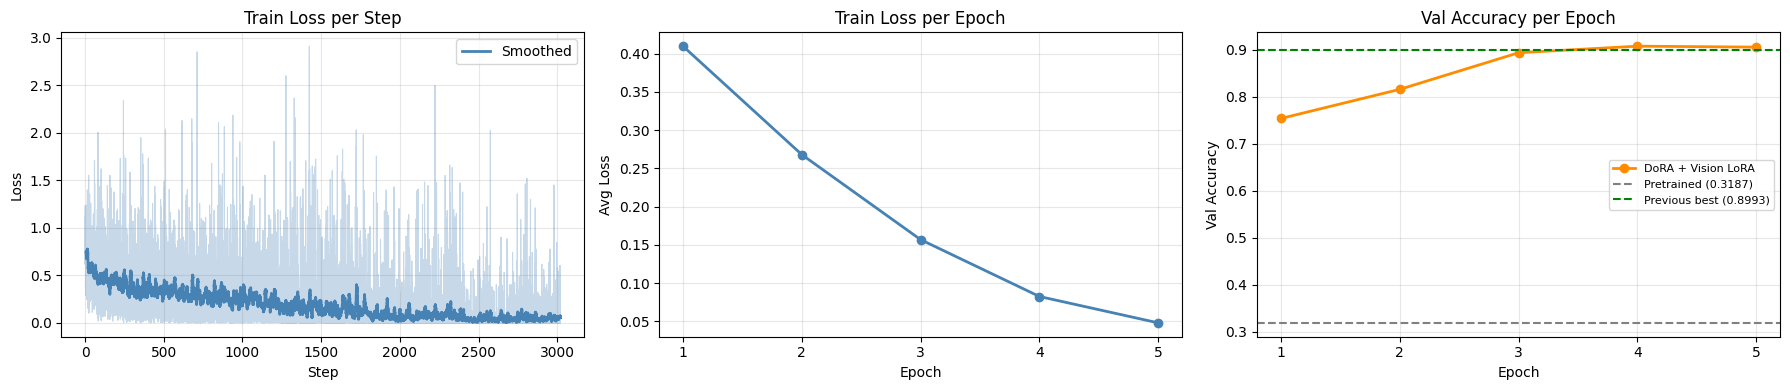


── Summary ──────────────────────────────────────────────
Epoch    Avg Loss     Val Accuracy
-----------------------------------
1        0.4097       0.7540
2        0.2680       0.8160
3        0.1568       0.8940
4        0.0826       0.9080
5        0.0481       0.9060

Best val accuracy: 0.9080 at epoch 4
Previous best leaderboard: 0.8993
Training complete.


In [9]:
from bitsandbytes.optim import PagedAdamW8bit
from transformers import get_cosine_schedule_with_warmup

EPOCHS       = 5
BATCH_SIZE   = 4
GRAD_ACCUM   = 4
LR           = 2e-4
WARMUP_RATIO = 0.03

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id":          run_id,
    "hyperparameters": {
        "epochs":               EPOCHS,
        "batch_size":           BATCH_SIZE,
        "grad_accum":           GRAD_ACCUM,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
        "lr":                   LR,
        "lora_r":               16,
        "lora_alpha":           32,
        "use_dora":             True,
        "vision_lora":          True,
        "target_modules":       "q+k+v+o text + q+k+v+out vision all 12 layers",
        "loss":                 "NLI_yes_no",
        "max_context_chars":    2000,
        "optimizer":            "PagedAdamW8bit",
    },
    "train_loss_per_step":    [],
    "train_loss_per_epoch":   [],
    "val_accuracy_per_epoch": [],
    "previous_best_leaderboard": 0.8993,
}

train_loader = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

optimizer    = PagedAdamW8bit(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

def plot_training(log):
    steps        = [s["step"] for s in log["train_loss_per_step"]]
    losses       = [s["loss"]  for s in log["train_loss_per_step"]]
    epoch_losses = log["train_loss_per_epoch"]
    val_accs     = log["val_accuracy_per_epoch"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(steps, losses, alpha=0.3, color="steelblue", linewidth=0.8)
    if len(losses) >= 30:
        smoothed = pd.Series(losses).rolling(30).mean()
        axes[0].plot(steps, smoothed, color="steelblue", linewidth=2, label="Smoothed")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Train Loss per Step")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses,
                 marker="o", color="steelblue", linewidth=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Loss")
    axes[1].set_title("Train Loss per Epoch")
    axes[1].set_xticks(range(1, EPOCHS+1)); axes[1].grid(alpha=0.3)

    axes[2].plot(range(1, len(val_accs)+1), val_accs,
                 marker="o", color="darkorange", linewidth=2, label="DoRA + Vision LoRA")
    axes[2].axhline(y=0.3187, color="gray",  linestyle="--", label="Pretrained (0.3187)")
    axes[2].axhline(y=0.8993, color="green", linestyle="--", label="Previous best (0.8993)")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val Accuracy")
    axes[2].set_title("Val Accuracy per Epoch")
    axes[2].set_xticks(range(1, EPOCHS+1))
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / f"dora_vision_training_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Training loop ─────────────────────────────────────────────────────────────
global_step = 0
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    optimizer.zero_grad()

    for step, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        inputs  = {k: v.to(model.device) if torch.is_tensor(v) else v
                   for k, v in inputs.items()}
        outputs = model(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        log["train_loss_per_step"].append({
            "step":  global_step,
            "epoch": epoch + 1,
            "loss":  outputs.loss.item(),
        })

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    print("Running val eval...")
    val_acc = evaluate(model, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    model.train()

    ckpt_path = LOG_DIR / f"dora_vision_ckpt_epoch{epoch+1}_{run_id}"
    model.save_pretrained(ckpt_path)
    torch.save({
        "epoch":                epoch + 1,
        "global_step":          global_step,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "log":                  log,
    }, LOG_DIR / f"dora_vision_trainer_state_epoch{epoch+1}_{run_id}.pt")
    with open(LOG_DIR / f"dora_vision_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

plot_training(log)
with open(LOG_DIR / f"dora_vision_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 35)
for i, (loss, acc) in enumerate(zip(log["train_loss_per_epoch"], log["val_accuracy_per_epoch"])):
    print(f"{i+1:<8} {loss:<12.4f} {acc:.4f}")
best_acc   = max(log["val_accuracy_per_epoch"])
best_epoch = log["val_accuracy_per_epoch"].index(best_acc) + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best leaderboard: 0.8993")
print("Training complete.")

In [10]:
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 4  # change to best epoch after training
CKPT_PATH = LOG_DIR / f"dora_vision_ckpt_epoch{EPOCH}_{run_id}"

print(f"Loading checkpoint: {CKPT_PATH}")

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
infer_model = PeftModel.from_pretrained(base, CKPT_PATH)
infer_model.eval()

test_results = []
for idx in tqdm(range(len(test_df)), desc="Test inference"):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
sub_name = f"submission_dora_vision_epoch{EPOCH}_{run_id}.csv"
submission_df.to_csv(sub_name, index=False)
print(f"Saved {sub_name}")
print(submission_df.head())
print(f"Shape: {submission_df.shape}")

del infer_model, base
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint: logs/dora_vision_ckpt_epoch4_20260430_124557


Test inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch4_20260430_124557.csv
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       0
3  test_02425       4
4  test_00930       2
Shape: (1008, 2)


In [11]:
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 5  # change to best epoch after training
CKPT_PATH = LOG_DIR / f"dora_vision_ckpt_epoch{EPOCH}_{run_id}"

print(f"Loading checkpoint: {CKPT_PATH}")

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
infer_model = PeftModel.from_pretrained(base, CKPT_PATH)
infer_model.eval()

test_results = []
for idx in tqdm(range(len(test_df)), desc="Test inference"):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
sub_name = f"submission_dora_vision_epoch{EPOCH}_{run_id}.csv"
submission_df.to_csv(sub_name, index=False)
print(f"Saved {sub_name}")
print(submission_df.head())
print(f"Shape: {submission_df.shape}")

del infer_model, base
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint: logs/dora_vision_ckpt_epoch5_20260430_124557


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Test inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch5_20260430_124557.csv
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       0
3  test_02425       4
4  test_00930       2
Shape: (1008, 2)


In [12]:
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 3  # change to best epoch after training
CKPT_PATH = LOG_DIR / f"dora_vision_ckpt_epoch{EPOCH}_{run_id}"

print(f"Loading checkpoint: {CKPT_PATH}")

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
infer_model = PeftModel.from_pretrained(base, CKPT_PATH)
infer_model.eval()

test_results = []
for idx in tqdm(range(len(test_df)), desc="Test inference"):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
sub_name = f"submission_dora_vision_epoch{EPOCH}_{run_id}.csv"
submission_df.to_csv(sub_name, index=False)
print(f"Saved {sub_name}")
print(submission_df.head())
print(f"Shape: {submission_df.shape}")

del infer_model, base
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint: logs/dora_vision_ckpt_epoch3_20260430_124557


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Test inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch3_20260430_124557.csv
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       0
3  test_02425       4
4  test_00930       2
Shape: (1008, 2)


In [13]:
# ── Resume DoRA + Vision LoRA training for 5 more epochs ─────────────────────
RESUME_EPOCH  = 5  # change to whatever epoch you're resuming from
RESUME_EPOCHS = 5
RESUME_LR     = 2e-4  # keep same LR or lower to 1e-4 if plateauing

resume_run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
resume_log = {
    "run_id":                resume_run_id,
    "resumed_from":          f"dora_vision_ckpt_epoch{RESUME_EPOCH}_{run_id}",
    "resume_epoch":          RESUME_EPOCH,
    "resume_lr":             RESUME_LR,
    "train_loss_per_step":   [],
    "train_loss_per_epoch":  [],
    "val_accuracy_per_epoch": [],
    "previous_best":         0.8993,
}

# Load checkpoint
print(f"Loading epoch {RESUME_EPOCH} checkpoint...")
from peft import PeftModel
from transformers import AutoModelForVision2Seq

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
model_resume = PeftModel.from_pretrained(
    base,
    LOG_DIR / f"dora_vision_ckpt_epoch{RESUME_EPOCH}_{run_id}",
    is_trainable=True,
)
model_resume.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# Dataloader
train_loader_resume = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

# Optimizer + scheduler
optimizer_resume    = PagedAdamW8bit(model_resume.parameters(), lr=RESUME_LR, weight_decay=0.01)
total_steps_resume  = (len(train_loader_resume) // GRAD_ACCUM) * RESUME_EPOCHS
warmup_steps_resume = max(1, int(total_steps_resume * 0.03))
scheduler_resume    = get_cosine_schedule_with_warmup(
    optimizer_resume,
    num_warmup_steps=warmup_steps_resume,
    num_training_steps=total_steps_resume,
)

# Training
global_step = 0
model_resume.train()

for epoch in range(RESUME_EPOCHS):
    actual_epoch = RESUME_EPOCH + epoch + 1
    total_loss   = 0
    optimizer_resume.zero_grad()

    for step, (inputs, labels) in enumerate(tqdm(train_loader_resume, desc=f"Epoch {actual_epoch}")):
        inputs  = {k: v.to(model_resume.device) if torch.is_tensor(v) else v
                   for k, v in inputs.items()}
        outputs = model_resume(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        resume_log["train_loss_per_step"].append({
            "step":         global_step,
            "actual_epoch": actual_epoch,
            "loss":         outputs.loss.item(),
        })

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model_resume.parameters(), 1.0)
            optimizer_resume.step()
            scheduler_resume.step()
            optimizer_resume.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader_resume)
    resume_log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {actual_epoch} | avg loss: {avg_loss:.4f}")

    print("Running val eval...")
    val_acc = evaluate(model_resume, val_df, DATA_DIR, n_samples=500, seed=epoch)
    resume_log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {actual_epoch} | val accuracy: {val_acc:.4f}")
    model_resume.train()

    ckpt_path = LOG_DIR / f"dora_vision_resume_epoch{actual_epoch}_{resume_run_id}"
    model_resume.save_pretrained(ckpt_path)
    torch.save({
        "actual_epoch":         actual_epoch,
        "global_step":          global_step,
        "optimizer_state_dict": optimizer_resume.state_dict(),
        "scheduler_state_dict": scheduler_resume.state_dict(),
        "resume_log":           resume_log,
    }, LOG_DIR / f"dora_vision_resume_trainer_state_epoch{actual_epoch}_{resume_run_id}.pt")
    with open(LOG_DIR / f"dora_vision_resume_log_{resume_run_id}.json", "w") as f:
        json.dump(resume_log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# Summary
print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 35)
for i, (loss, acc) in enumerate(zip(resume_log["train_loss_per_epoch"],
                                     resume_log["val_accuracy_per_epoch"])):
    print(f"{RESUME_EPOCH+i+1:<8} {loss:<12.4f} {acc:.4f}")

best_acc   = max(resume_log["val_accuracy_per_epoch"])
best_epoch = resume_log["val_accuracy_per_epoch"].index(best_acc) + RESUME_EPOCH + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best leaderboard: 0.8993")

Loading epoch 5 checkpoint...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,575,232 || all params: 512,057,536 || trainable%: 0.8935
RAM: 7.7/16.7 GB | VRAM: 0.91 GB


Epoch 6:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 6 | avg loss: 0.1521
Running val eval...


...

Val accuracy (500 samples): 0.8960
Epoch 9 | val accuracy: 0.8960
Saved: logs/dora_vision_resume_epoch9_20260430_175706
RAM: 7.7/16.7 GB | VRAM: 0.94 GB


Epoch 10:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 10 | avg loss: 0.0319
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8980
Epoch 10 | val accuracy: 0.8980
Saved: logs/dora_vision_resume_epoch10_20260430_175706
RAM: 7.7/16.7 GB | VRAM: 0.94 GB

── Summary ──────────────────────────────────────────────
Epoch    Avg Loss     Val Accuracy
-----------------------------------
6        0.1521       0.8800
7        0.1283       0.8820
8        0.0850       0.8920
9        0.0488       0.8960
10       0.0319       0.8980

Best val accuracy: 0.8980 at epoch 10
Previous best leaderboard: 0.8993


In [14]:
# ── Generate submissions for DoRA resume epochs 6-10 ─────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

for actual_epoch in [6, 7, 8, 9, 10]:
    print(f"\n{'='*60}")
    print(f"Generating submission for epoch {actual_epoch}")
    print(f"{'='*60}")

    ckpt_path = LOG_DIR / f"dora_vision_resume_epoch{actual_epoch}_{resume_run_id}"
    print(f"Loading checkpoint: {ckpt_path}")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base, ckpt_path)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"Epoch {actual_epoch} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name = f"submission_dora_vision_epoch{actual_epoch}_{resume_run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved {sub_name}")
    print(f"Shape: {submission_df.shape}")

    del infer_model, base
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll 5 submissions generated.")


Generating submission for epoch 6
Loading checkpoint: logs/dora_vision_resume_epoch6_20260430_175706


Epoch 6 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch6_20260430_175706.csv
Shape: (1008, 2)

Generating submission for epoch 7
Loading checkpoint: logs/dora_vision_resume_epoch7_20260430_175706


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 7 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

...

Epoch 9 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch9_20260430_175706.csv
Shape: (1008, 2)

Generating submission for epoch 10
Loading checkpoint: logs/dora_vision_resume_epoch10_20260430_175706


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 10 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_dora_vision_epoch10_20260430_175706.csv
Shape: (1008, 2)

All 5 submissions generated.


In [16]:
# ── Full val error analysis ───────────────────────────────────────────────────
# Use the epoch 9 checkpoint
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 9
CKPT_PATH = LOG_DIR / f"dora_vision_resume_epoch{EPOCH}_{resume_run_id}"

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
analysis_model = PeftModel.from_pretrained(base, CKPT_PATH)
analysis_model.eval()

val_results = []
for idx in tqdm(range(len(val_df)), desc="Full val eval"):
    row   = val_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred  = score_choices_nli(analysis_model, processor, image, row, row["choices"])
    val_results.append({
        "id":          row["id"],
        "pred":        pred,
        "answer":      int(row["answer"]),
        "correct":     pred == int(row["answer"]),
        "subject":     row["subject"],
        "grade":       row["grade"],
        "task":        row["task"],
        "num_choices": row["num_choices"],
        "has_lecture": pd.notna(row.get("lecture", None)) and bool(row["lecture"]),
        "has_hint":    pd.notna(row.get("hint", None)) and bool(row["hint"]),
    })

results_df = pd.DataFrame(val_results)
overall    = results_df["correct"].mean()
print(f"Overall val accuracy: {overall:.4f} ({results_df['correct'].sum()}/{len(results_df)})")

print("\n── By subject ───────────────────────────────────────────")
print(results_df.groupby("subject")["correct"].agg(["mean", "count"]).round(4))

print("\n── By grade ─────────────────────────────────────────────")
print(results_df.groupby("grade")["correct"].agg(["mean", "count"]).round(4))

print("\n── By task ──────────────────────────────────────────────")
print(results_df.groupby("task")["correct"].agg(["mean", "count"]).round(4))

print("\n── By num_choices ───────────────────────────────────────")
print(results_df.groupby("num_choices")["correct"].agg(["mean", "count"]).round(4))

print("\n── By context availability ──────────────────────────────")
print(results_df.groupby(["has_lecture", "has_hint"])["correct"].agg(["mean", "count"]).round(4))

del analysis_model, base
gc.collect()
torch.cuda.empty_cache()

/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Full val eval:   0%|          | 0/1048 [00:00<?, ?it/s]

Overall val accuracy: 0.8960 (939/1048)

── By subject ───────────────────────────────────────────
                    mean  count
subject                        
language science  0.8214     28
natural science   0.8958    777
social science    0.9053    243

── By grade ─────────────────────────────────────────────
           mean  count
grade                 
grade1   1.0000      1
grade10  0.0000      1
grade12  1.0000      8
grade2   0.9167     36
grade3   0.9057    106
grade4   0.9302    172
grade5   0.9412    119
grade6   0.9010    192
grade7   0.9066    182
grade8   0.8268    231

── By task ──────────────────────────────────────────────
                 mean  count
task                        
closed choice  0.8995   1015
true-or false  0.7879     33

── By num_choices ───────────────────────────────────────
               mean  count
num_choices               
2            0.8811    244
3            0.9567    508
4            0.8849    252
5            0.3409     44

── By con

In [17]:
# Analyze grade 8 errors
grade8 = results_df[results_df["grade"] == "grade8"]
grade8_wrong = grade8[grade8["correct"] == False]

print(f"Grade 8: {grade8['correct'].sum()}/{len(grade8)} correct ({grade8['correct'].mean():.4f})")
print(f"Wrong predictions: {len(grade8_wrong)}")
print()

# What subjects are the grade 8 errors in?
print("Grade 8 errors by subject:")
print(grade8_wrong["subject"].value_counts())
print()

# What's the num_choices distribution for grade 8 errors?
print("Grade 8 errors by num_choices:")
print(grade8_wrong["num_choices"].value_counts())
print()

# Show a few wrong examples
wrong_ids = grade8_wrong["id"].values[:5]
for wid in wrong_ids:
    row = val_df[val_df["id"] == wid].iloc[0]
    res = grade8_wrong[grade8_wrong["id"] == wid].iloc[0]
    print(f"{'='*60}")
    print(f"Question: {row['question'][:150]}")
    print(f"Subject: {row['subject']} | Choices: {row['num_choices']}")
    print(f"Predicted: {chr(65+res['pred'])} | Correct: {chr(65+res['answer'])}")
    print(f"Choices: {row['choices']}")
    print()

Grade 8: 191/231 correct (0.8268)
Wrong predictions: 40

Grade 8 errors by subject:
subject
natural science    40
Name: count, dtype: int64

Grade 8 errors by num_choices:
num_choices
5    29
2     6
4     3
3     2
Name: count, dtype: int64

Question: What is the probability that a Cepaea snail produced by this cross will be homozygous recessive for the shell banding gene?
Subject: natural science | Choices: 5
Predicted: C | Correct: A
Choices: ['2/4', '4/4', '0/4', '3/4', '1/4']

Question: What is the probability that a Cepaea snail produced by this cross will be homozygous recessive for the shell banding gene?
Subject: natural science | Choices: 5
Predicted: B | Correct: E
Choices: ['2/4', '0/4', '3/4', '1/4', '4/4']

Question: What is the probability that a pea plant produced by this cross will be homozygous recessive for the stem height gene?
Subject: natural science | Choices: 5
Predicted: C | Correct: D
Choices: ['3/4', '1/4', '0/4', '2/4', '4/4']

Question: What is the expected

In [18]:
# ── Analyze non-grade-8 errors ────────────────────────────────────────────────
non_grade8_wrong = results_df[(results_df["correct"] == False) & 
                               (results_df["grade"] != "grade8")]

print(f"Non-grade-8 errors: {len(non_grade8_wrong)}")
print()

print("By subject:")
print(non_grade8_wrong["subject"].value_counts())
print()

print("By grade:")
print(non_grade8_wrong["grade"].value_counts())
print()

print("By num_choices:")
print(non_grade8_wrong["num_choices"].value_counts())
print()

print("By context:")
print(non_grade8_wrong.groupby(["has_lecture", "has_hint"]).size())
print()

# Show 5 examples
for i, (_, res) in enumerate(non_grade8_wrong.head(5).iterrows()):
    row = val_df[val_df["id"] == res["id"]].iloc[0]
    print(f"{'='*60}")
    print(f"Grade: {res['grade']} | Subject: {res['subject']} | Choices: {res['num_choices']}")
    print(f"Question: {row['question'][:150]}")
    print(f"Choices: {row['choices']}")
    print(f"Predicted: {chr(65+res['pred'])} | Correct: {chr(65+res['answer'])}")
    print()

Non-grade-8 errors: 69

By subject:
subject
natural science     41
social science      23
language science     5
Name: count, dtype: int64

By grade:
grade
grade6     19
grade7     17
grade4     12
grade3     10
grade5      7
grade2      3
grade10     1
Name: count, dtype: int64

By num_choices:
num_choices
4    26
2    23
3    20
Name: count, dtype: int64

By context:
has_lecture  has_hint
False        False        6
             True         9
True         False       19
             True        35
dtype: int64

Grade: grade5 | Subject: language science | Choices: 4
Question: Based on clues in the text, how did fossil evidence help scientists explain the huge number of beetle species?
Choices: ["It helped scientists learn that beetle species only appeared after Earth's most recent ice age.", 'It helped scientists figure out which ancient animal species were most likely to eat beetles.', "It let scientists compare ancient beetles' wing structure to modern beetles' wing structure.", 'I

In [19]:
# Check if model has position bias — does it favor earlier choices?
correct_positions = results_df[results_df["correct"] == True]["answer"].value_counts().sort_index()
wrong_positions   = results_df[results_df["correct"] == False]["pred"].value_counts().sort_index()

print("Correct answer position distribution (val set):")
print(correct_positions)
print()
print("Wrong prediction position distribution:")
print(wrong_positions)
print()
print("Overall prediction distribution:")
print(results_df["pred"].value_counts().sort_index())

Correct answer position distribution (val set):
answer
0    309
1    339
2    230
3     59
4      2
Name: count, dtype: int64

Wrong prediction position distribution:
pred
0    36
1    39
2    18
3    12
4     4
Name: count, dtype: int64

Overall prediction distribution:
pred
0    345
1    378
2    248
3     71
4      6
Name: count, dtype: int64


In [20]:
# ── Categorize errors ─────────────────────────────────────────────────────────
wrong = results_df[results_df["correct"] == False].copy()

# Tag diagram reading errors (questions asking to describe a diagram)
wrong["is_diagram"] = wrong["id"].map(
    lambda wid: "Complete the text to describe the diagram" in 
    val_df[val_df["id"] == wid]["question"].values[0]
)

# Tag genetics/probability errors
wrong["is_genetics"] = wrong["grade"].isin(["grade8"]) & \
                       (wrong["num_choices"] == 5)

print(f"Total errors: {len(wrong)}")
print(f"Diagram reading errors: {wrong['is_diagram'].sum()}")
print(f"Genetics/probability errors: {wrong['is_genetics'].sum()}")
print(f"Other errors: {(~wrong['is_diagram'] & ~wrong['is_genetics']).sum()}")
print()

# What are the other errors?
other = wrong[~wrong["is_diagram"] & ~wrong["is_genetics"]]
print(f"Other error breakdown by subject:")
print(other["subject"].value_counts())
print()
print(f"Other error breakdown by num_choices:")
print(other["num_choices"].value_counts())

Total errors: 109
Diagram reading errors: 5
Genetics/probability errors: 29
Other errors: 75

Other error breakdown by subject:
subject
natural science     47
social science      23
language science     5
Name: count, dtype: int64

Other error breakdown by num_choices:
num_choices
4    29
2    24
3    22
Name: count, dtype: int64


In [21]:
# ── Look at other errors in detail ────────────────────────────────────────────
other_ids = other["id"].values

for i, wid in enumerate(other_ids[:10]):
    row = val_df[val_df["id"] == wid].iloc[0]
    res = other[other["id"] == wid].iloc[0]
    print(f"{'='*60}")
    print(f"Grade: {res['grade']} | Subject: {res['subject']} | Choices: {res['num_choices']}")
    print(f"Has lecture: {res['has_lecture']} | Has hint: {res['has_hint']}")
    print(f"Question: {row['question'][:200]}")
    print(f"Choices: {row['choices']}")
    print(f"Predicted: {chr(65+res['pred'])} | Correct: {chr(65+res['answer'])}")
    if pd.notna(row.get('hint', None)) and row['hint']:
        print(f"Hint (first 200): {row['hint'][:200]}")
    print()

Grade: grade5 | Subject: language science | Choices: 4
Has lecture: True | Has hint: True
Question: Based on clues in the text, how did fossil evidence help scientists explain the huge number of beetle species?
Choices: ["It helped scientists learn that beetle species only appeared after Earth's most recent ice age.", 'It helped scientists figure out which ancient animal species were most likely to eat beetles.', "It let scientists compare ancient beetles' wing structure to modern beetles' wing structure.", 'It let scientists compare the number of extinct beetles to the number of other extinct species.']
Predicted: A | Correct: D
Hint (first 200): Read the text about beetles.
There are more species of beetles than any other life-form on Earth. About 380,000 species of beetles are known to exist, and more are discovered all the time. There are s

Grade: grade6 | Subject: natural science | Choices: 4
Has lecture: True | Has hint: True
Question: In this food web, which organism contains m

In [23]:
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 9
CKPT_PATH = LOG_DIR / f"dora_vision_resume_epoch{EPOCH}_{resume_run_id}"

print(f"Loading checkpoint: {CKPT_PATH}")

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
analysis_model = PeftModel.from_pretrained(base, CKPT_PATH)
analysis_model.eval()
print("Loaded.")

Loading checkpoint: logs/dora_vision_resume_epoch9_20260430_175706


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded.


In [24]:
# ── Test adaptive image splitting on val set ──────────────────────────────────
def score_choices_nli_adaptive(model, processor, image, row, choices, max_context_chars=2000):
    """Use image splitting for diagram-heavy questions."""
    question = row["question"].lower()
    is_diagram_question = any(kw in question for kw in [
        "food web", "diagram", "complete the text", "food chain",
        "moved across", "consumer", "omnivore", "matter that",
        "primary consumer", "tertiary consumer", "secondary consumer",
        "which organism", "population", "community"
    ])

    if is_diagram_question:
        processor.image_processor.do_image_splitting = True
        processor.image_processor.size = {"longest_edge": 2048}

    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, include_answer=False,
                                  max_context_chars=max_context_chars)
        try:
            inputs = processor(
                text=[prompt], images=[image],
                return_tensors="pt", padding=True
            )
            inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                      for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
                logits  = outputs.logits[:, -1, :]

            score = logits[0, yes_token].item() - logits[0, no_token].item()
        except Exception as e:
            print(f"Error on diagram question: {e} — falling back to standard")
            score = 0.0

        scores.append(score)

        del outputs, logits, inputs
        torch.cuda.empty_cache()

    # Always reset
    processor.image_processor.do_image_splitting = False
    processor.image_processor.size = {"longest_edge": 512}

    return int(torch.tensor(scores).argmax().item())

# ── Run on full val set ───────────────────────────────────────────────────────
analysis_model.eval()
correct    = 0
n_diagram  = 0
d_correct  = 0
n_standard = 0
s_correct  = 0

for idx in tqdm(range(len(val_df)), desc="Adaptive val eval"):
    row   = val_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB")

    question = row["question"].lower()
    is_diagram = any(kw in question for kw in [
        "food web", "diagram", "complete the text", "food chain",
        "moved across", "consumer", "omnivore", "matter that",
        "primary consumer", "tertiary consumer", "secondary consumer",
        "which organism", "population", "community"
    ])

    pred = score_choices_nli_adaptive(
        analysis_model, processor, image, row, row["choices"]
    )

    is_correct = pred == int(row["answer"])
    correct += is_correct

    if is_diagram:
        n_diagram += 1
        d_correct += is_correct
    else:
        n_standard += 1
        s_correct  += is_correct

total_acc    = correct / len(val_df)
diagram_acc  = d_correct  / n_diagram  if n_diagram  > 0 else 0
standard_acc = s_correct  / n_standard if n_standard > 0 else 0

print(f"\nResults:")
print(f"Overall accuracy:  {total_acc:.4f} ({correct}/{len(val_df)})")
print(f"Diagram questions: {diagram_acc:.4f} ({d_correct}/{n_diagram})")
print(f"Standard questions:{standard_acc:.4f} ({s_correct}/{n_standard})")
print(f"\nPrevious overall:  0.8960")
print(f"Difference:        {total_acc - 0.8960:+.4f}")

Adaptive val eval:   0%|          | 0/1048 [00:00<?, ?it/s]


Results:
Overall accuracy:  0.8979 (941/1048)
Diagram questions: 0.6415 (34/53)
Standard questions:0.9116 (907/995)

Previous overall:  0.8960
Difference:        +0.0019


In [25]:
# ── Generate submission with adaptive scoring ─────────────────────────────────
test_results = []

for idx in tqdm(range(len(test_df)), desc="Adaptive test inference"):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli_adaptive(analysis_model, processor, image, row, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
submission_df.to_csv("submission_adaptive.csv", index=False)
print(f"Saved submission_adaptive.csv")
print(f"Shape: {submission_df.shape}")

Adaptive test inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_adaptive.csv
Shape: (1008, 2)
